# STEP 1 — FedAvg EQUAL WEIGHTING
# Same as Phase 4 FedAvg but with equal contribution
# from all three hospitals regardless of dataset size
#
# Change from weighted:
#   H1: 21.5%  H2: 3.5%   H3: 75.0%
# To equal:
#   H1: 33.3%  H2: 33.3%  H3: 33.3%
#
# Purpose: Allow Hospital 2 (Coimbra) to receive
# meaningful knowledge from larger hospitals
# without being dominated by dataset size

### Colab config

In [ ]:
# First cell in Colab
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# Should print: Tesla T4 or similar

# Install dependencies
!pip install torchvision torch -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available : True
GPU name      : Tesla T4


### Setting Working Directory

In [ ]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
os.chdir('/content/drive/MyDrive/BREAST_CANCER_FL/')
print("Changing to root directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: '/content/drive/My Drive/BREAST_CANCER_FL'
Changing to root directory...
Working in: '/content/drive/MyDrive/BREAST_CANCER_FL'


### 1. Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import WeightedRandomSampler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import os
from PIL import Image
from tqdm import tqdm
import json
import pickle
import copy
from collections import Counter

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Import model architectures
import sys
sys.path.append('models')
from model_architectures import Hospital1_MLP, Hospital2_MLP, Hospital3_CNN

# Torchvision for image transforms
from torchvision import transforms

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

EMBEDDING_DIM =64

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Create results directories
os.makedirs('results/federated_learning', exist_ok=True)
os.makedirs('models/federated', exist_ok=True)

print("\n✓ All libraries imported successfully!")

Using device: cuda

✓ All libraries imported successfully!


### 2. Define Federated Learning Utility Functions

In [ ]:
# FEDERATED LEARNING UTILITY FUNCTIONS

# FUNCTION 1 — get_shared_head_weights
# Extracts shared head weights from any hospital model
# These are the ONLY weights exchanged in federation
# Works identically for all three hospitals because
# SharedClassificationHead is identical across all
def get_shared_head_weights(model):
    """
    Extract shared head weights from a hospital model.

    Works for Hospital1_MLP, Hospital2_MLP, Hospital3_CNN
    because all three use the same SharedClassificationHead.

    Args:
        model : any hospital model

    Returns:
        state_dict of shared_head — ready for FedAvg
    """
    return {
        k: v.clone()
        for k, v in model.shared_head.state_dict().items()
    }


# FUNCTION 2 — set_shared_head_weights
# Loads globally averaged shared head weights back
# into each hospital model after FedAvg
def set_shared_head_weights(model, weights):
    """
    Load global shared head weights into a hospital model.

    Args:
        model   : any hospital model
        weights : globally averaged state_dict from FedAvg
    """
    model.shared_head.load_state_dict(weights)


# FUNCTION 3 — federated_averaging
# Performs weighted FedAvg on shared head weights
# Mathematically valid because all shared heads are
# identical in architecture and input dimension (64-dim)
def federated_averaging(weights_list, dataset_sizes):
    """
    Weighted federated averaging of shared head weights.

    FedAvg formula:
        global_w = sum(n_i / N * w_i) for all hospitals i
        where n_i = hospital i dataset size
              N   = total samples across all hospitals

    Args:
        weights_list  : list of shared_head state_dicts
                        one per hospital
        dataset_sizes : list of training sample counts
                        [570, 92, 1664] for H1, H2, H3

    Returns:
        avg_weights : globally averaged state_dict
    """
    total_size = sum(dataset_sizes)
    avg_weights = {}

    for key in weights_list[0].keys():
        # Weighted sum across all hospitals
        avg_weights[key] = sum(
            weights_list[i][key].float() *
            (dataset_sizes[i] / total_size)
            for i in range(len(weights_list))
        )

    return avg_weights


# FUNCTION 4 — aggregate_prototypes
# FedProto aggregation — averages class prototypes
# instead of weights
# Alternative to FedAvg for heterogeneous FL
def aggregate_prototypes(prototypes_list, dataset_sizes):
    """
    Weighted aggregation of class prototypes for FedProto.

    Each hospital contributes prototypes weighted by
    their dataset size — same weighting as FedAvg.

    Args:
        prototypes_list : list of dicts
                          each dict = {class_id: prototype_tensor}
                          one dict per hospital
        dataset_sizes   : list of training sample counts

    Returns:
        global_prototypes : dict {class_id: global_prototype}
    """
    total_size    = sum(dataset_sizes)
    num_classes   = len(prototypes_list[0])
    global_protos = {}

    for cls in range(num_classes):
        # Weighted average of class prototypes
        global_protos[cls] = sum(
            prototypes_list[i][cls].float() *
            (dataset_sizes[i] / total_size)
            for i in range(len(prototypes_list))
        )

    return global_protos


# FUNCTION 5 — train_local_epoch
# Trains one hospital model for one epoch locally
# Supports dual optimizer for encoder + shared head
def train_local_epoch(
    model,
    dataloader,
    criterion,
    optimizer_encoder,
    optimizer_head,
    device
):
    """
    Train hospital model for one local epoch.

    Uses dual optimizers:
        optimizer_encoder : updates private encoder
        optimizer_head    : updates shared head

    For Hospital 3 pass optimizer_projection as
    optimizer_encoder since backbone is frozen.

    Args:
        model            : any hospital model
        dataloader       : training DataLoader
        criterion        : BCEWithLogitsLoss
        optimizer_encoder: Adam for encoder/projection
        optimizer_head   : Adam for shared head
        device           : cpu or cuda

    Returns:
        epoch_loss : average loss
        epoch_acc  : accuracy
    """
    model.train()
    running_loss = 0.0
    all_preds    = []
    all_labels   = []

    for inputs, labels in dataloader:
        inputs = inputs.to(device).float()
        labels = labels.to(device).float().view(-1, 1)

        # Zero both optimizers
        optimizer_encoder.zero_grad(set_to_none=True)
        optimizer_head.zero_grad(set_to_none=True)

        # Forward pass
        outputs = model(inputs)
        loss    = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Step both optimizers
        optimizer_encoder.step()
        optimizer_head.step()

        # Track metrics
        # Threshold at 0.0 for raw logits
        # logit > 0.0 equivalent to sigmoid(logit) > 0.5
        running_loss += loss.item() * inputs.size(0)
        preds = (outputs.detach() > 0.0).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


# FUNCTION 6 — evaluate_federated_model
# Evaluates any hospital model on its test set
# Returns full metrics dict for comparison table
def evaluate_federated_model(model, dataloader, criterion, device):
    """
    Evaluate hospital model on test set.

    Args:
        model      : any hospital model
        dataloader : test DataLoader
        criterion  : BCEWithLogitsLoss
        device     : cpu or cuda

    Returns:
        metrics dict with loss, accuracy, precision,
        recall, f1, auc_roc
    """
    model.eval()
    running_loss = 0.0
    all_preds    = []
    all_probs    = []
    all_labels   = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).float().view(-1, 1)

            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            # Threshold at 0.0 for raw logits
            preds = (outputs > 0.0).float()

            # Apply sigmoid for AUC computation
            probs = torch.sigmoid(outputs)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Flatten for sklearn
    all_labels = np.array(all_labels).flatten()
    all_preds  = np.array(all_preds).flatten()
    all_probs  = np.array(all_probs).flatten()

    epoch_loss = running_loss / len(dataloader.dataset)

    try:
        auc_roc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc_roc = 0.0

    metrics = {
        'loss'     : epoch_loss,
        'accuracy' : accuracy_score(all_labels, all_preds),
        'precision': precision_score(
            all_labels, all_preds, zero_division=0
        ),
        'recall'   : recall_score(
            all_labels, all_preds, zero_division=0
        ),
        'f1'       : f1_score(
            all_labels, all_preds, zero_division=0
        ),
        'auc_roc'  : auc_roc
    }

    return metrics


# FUNCTION 7 — evaluate_all_hospitals
# Evaluates all three hospitals after each FL round
# Returns combined results for comparison
def evaluate_all_hospitals(
    models,
    dataloaders,
    criterion,
    device,
    hospital_names=None
):
    """
    Evaluate all hospital models and return combined results.

    Args:
        models        : list [hospital1_model, hospital2_model,
                              hospital3_model]
        dataloaders   : list [test_loader_wdbc,
                              test_loader_coimbra,
                              test_loader_breakhis]
        criterion     : BCEWithLogitsLoss
        device        : cpu or cuda
        hospital_names: optional list of name strings

    Returns:
        results : dict {hospital_name: metrics_dict}
    """
    if hospital_names is None:
        hospital_names = [
            'Hospital 1 (WDBC)',
            'Hospital 2 (Coimbra)',
            'Hospital 3 (BreakHis)'
        ]

    results = {}
    for model, loader, name in zip(
        models, dataloaders, hospital_names
    ):
        metrics = evaluate_federated_model(
            model, loader, criterion, device
        )
        results[name] = metrics

    return results


# FUNCTION 8 — print_round_summary
# Prints a clean per-round summary during FL training
def print_round_summary(round_num, results, algorithm='FedAvg'):
    """
    Print clean summary after each federated round.

    Args:
        round_num : current FL round number
        results   : dict from evaluate_all_hospitals()
        algorithm : 'FedAvg' or 'FedProto'
    """
    print(f"\n  Round {round_num:02d} [{algorithm}] Results:")
    print(f"  {'Hospital':<25} {'Acc':>6} {'F1':>6} "
          f"{'Recall':>8} {'AUC':>6}")
    print(f"  {'─'*55}")
    for name, metrics in results.items():
        print(f"  {name:<25} "
              f"{metrics['accuracy']:>6.4f} "
              f"{metrics['f1']:>6.4f} "
              f"{metrics['recall']:>8.4f} "
              f"{metrics['auc_roc']:>6.4f}")


# Confirming all utility functions defined
print(" Federated learning utility functions defined:")
print("   - get_shared_head_weights()  : extract shared head")
print("   - set_shared_head_weights()  : load global weights")
print("   - federated_averaging()      : FedAvg aggregation")
print("   - aggregate_prototypes()     : FedProto aggregation")
print("   - train_local_epoch()        : local training step")
print("   - evaluate_federated_model() : evaluate one hospital")
print("   - evaluate_all_hospitals()   : evaluate all hospitals")
print("   - print_round_summary()      : per-round display")

 Federated learning utility functions defined:
   - get_shared_head_weights()  : extract shared head
   - set_shared_head_weights()  : load global weights
   - federated_averaging()      : FedAvg aggregation
   - aggregate_prototypes()     : FedProto aggregation
   - train_local_epoch()        : local training step
   - evaluate_federated_model() : evaluate one hospital
   - evaluate_all_hospitals()   : evaluate all hospitals
   - print_round_summary()      : per-round display


### Reinitializing all three models from Phase 3 trained weights

In [ ]:
# Reinitializing all three models from Phase 3 trained weights
# Fresh start — same starting point as Phase 4 weighted FedAvg
# Ensures fair comparison between weighted and equal FedAvg
print("\n Loading Phase 3 trained weights...")

model_h1_eq = Hospital1_MLP(input_size=23, dropout_rate=0.3).to(device)
model_h1_eq.load_state_dict(
    torch.load('models/trained/hospital1_local.pth', map_location=device)
)

model_h2_eq = Hospital2_MLP(input_size=9, dropout_rate=0.3).to(device)
model_h2_eq.load_state_dict(
    torch.load('models/trained/hospital2_local.pth', map_location=device)
)

model_h3_eq = Hospital3_CNN(dropout_rate=0.2).to(device)
model_h3_eq.load_state_dict(
    torch.load('models/trained/hospital3_local.pth', map_location=device)
)

print("    Hospital 1 weights loaded")
print("    Hospital 2 weights loaded")
print("    Hospital 3 weights loaded")

# Defining equal dataset sizes — all set to 1
# This makes federated_averaging() give equal 33.3% weight
# to each hospital regardless of actual sample count
equal_sizes = [1, 1, 1]

print(f"\n   Equal weights configured: {equal_sizes}")
print(f"   Each hospital contributes: 33.3%")


 Loading Phase 3 trained weights...
    Hospital 1 weights loaded
    Hospital 2 weights loaded
    Hospital 3 weights loaded

   Equal weights configured: [1, 1, 1]
   Each hospital contributes: 33.3%


### Loading all datasets

In [ ]:
# These loaders were defined in 03_local_training.ipynb
# Must redefine here since Colab notebooks don't share memory

BASE_PATH = '/content/drive/MyDrive/BREAST_CANCER_FL/'

print("="*70)
print("  LOADING ALL HOSPITAL DATASETS")
print("="*70)

# Hospital 1 — WDBC
print("\n Loading Hospital 1 (WDBC)...")

X_train_h1 = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/wdbc/X_train.csv')
).values
y_train_h1 = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/wdbc/y_train.csv')
).values.flatten()
X_test_h1  = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/wdbc/X_test.csv')
).values
y_test_h1  = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/wdbc/y_test.csv')
).values.flatten()

assert X_train_h1.shape[1] == 23, "H1 feature count mismatch"
assert X_train_h1.shape[0] == y_train_h1.shape[0], "H1 train size mismatch"

train_dataset_h1 = TensorDataset(
    torch.FloatTensor(X_train_h1),
    torch.FloatTensor(y_train_h1)
)
test_dataset_h1 = TensorDataset(
    torch.FloatTensor(X_test_h1),
    torch.FloatTensor(y_test_h1)
)

generator_h1 = torch.Generator()
generator_h1.manual_seed(42)

train_loader_h1 = DataLoader(
    train_dataset_h1, batch_size=32,
    shuffle=True, generator=generator_h1
)
test_loader_h1 = DataLoader(
    test_dataset_h1, batch_size=32, shuffle=False
)

print(f"    Train : {len(train_dataset_h1)} samples "
      f"| Classes : {Counter(y_train_h1.astype(int))}")
print(f"    Test  : {len(test_dataset_h1)} samples "
      f"| Features: {X_train_h1.shape[1]}")

# Hospital 2 — Coimbra
print("\n Loading Hospital 2 (Coimbra)...")

X_train_h2 = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/coimbra/X_train.csv')
).values
y_train_h2 = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/coimbra/y_train.csv')
).values.flatten()
X_test_h2  = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/coimbra/X_test.csv')
).values
y_test_h2  = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/coimbra/y_test.csv')
).values.flatten()

assert X_train_h2.shape[1] == 9, "H2 feature count mismatch"
assert X_train_h2.shape[0] == y_train_h2.shape[0], "H2 train size mismatch"

train_dataset_h2 = TensorDataset(
    torch.FloatTensor(X_train_h2),
    torch.FloatTensor(y_train_h2)
)
test_dataset_h2 = TensorDataset(
    torch.FloatTensor(X_test_h2),
    torch.FloatTensor(y_test_h2)
)

generator_h2 = torch.Generator()
generator_h2.manual_seed(42)

train_loader_h2 = DataLoader(
    train_dataset_h2, batch_size=16,
    shuffle=True, generator=generator_h2
)
test_loader_h2 = DataLoader(
    test_dataset_h2, batch_size=16, shuffle=False
)

print(f"    Train : {len(train_dataset_h2)} samples "
      f"| Classes : {Counter(y_train_h2.astype(int))}")
print(f"    Test  : {len(test_dataset_h2)} samples "
      f"| Features: {X_train_h2.shape[1]}")

# Hospital 3 — BreakHis
print("\n Loading Hospital 3 (BreakHis)...")

class BreakHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.images    = []
        self.labels    = []
        valid_ext      = ('.png', '.jpg', '.jpeg')

        benign_dir = os.path.join(root_dir, 'benign')
        if os.path.exists(benign_dir):
            for img_name in os.listdir(benign_dir):
                if img_name.lower().endswith(valid_ext):
                    self.images.append(
                        os.path.join(benign_dir, img_name)
                    )
                    self.labels.append(0)

        malignant_dir = os.path.join(root_dir, 'malignant')
        if os.path.exists(malignant_dir):
            for img_name in os.listdir(malignant_dir):
                if img_name.lower().endswith(valid_ext):
                    self.images.append(
                        os.path.join(malignant_dir, img_name)
                    )
                    self.labels.append(1)

        assert len(self.images) > 0, f"No images in {root_dir}"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform_h3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform_h3 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset_h3 = BreakHisDataset(
    os.path.join(BASE_PATH, 'data/processed/breakhis/train'),
    transform=train_transform_h3
)
test_dataset_h3 = BreakHisDataset(
    os.path.join(BASE_PATH, 'data/processed/breakhis/test'),
    transform=test_transform_h3
)

class_weights_h3 = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_dataset_h3.labels
)
sample_weights_h3 = [
    class_weights_h3[label]
    for label in train_dataset_h3.labels
]
sampler_h3 = WeightedRandomSampler(
    weights=sample_weights_h3,
    num_samples=len(sample_weights_h3),
    replacement=True
)

train_loader_h3 = DataLoader(
    train_dataset_h3, batch_size=32,
    sampler=sampler_h3, num_workers=2, pin_memory=True
)
test_loader_h3 = DataLoader(
    test_dataset_h3, batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"    Train : {len(train_dataset_h3):,} images "
      f"| Benign: {train_dataset_h3.labels.count(0)} "
      f"Malignant: {train_dataset_h3.labels.count(1)}")
print(f"    Test  : {len(test_dataset_h3):,} images")

# Dataset sizes for FL reference
dataset_sizes = [
    len(train_dataset_h1),
    len(train_dataset_h2),
    len(train_dataset_h3)
]

print(f"\n{'='*45}")
print(f"  ALL DATASETS LOADED SUCCESSFULLY")
print(f"{'='*45}")
print(f"  H1 train : {dataset_sizes[0]:,}")
print(f"  H2 train : {dataset_sizes[1]:,}")
print(f"  H3 train : {dataset_sizes[2]:,}")
print(f"  Total    : {sum(dataset_sizes):,}")
print(f"{'='*45}")

  LOADING ALL HOSPITAL DATASETS

 Loading Hospital 1 (WDBC)...
    Train : 570 samples | Classes : Counter({np.int64(1): 285, np.int64(0): 285})
    Test  : 114 samples | Features: 23

 Loading Hospital 2 (Coimbra)...
    Train : 92 samples | Classes : Counter({np.int64(1): 51, np.int64(0): 41})
    Test  : 24 samples | Features: 9

 Loading Hospital 3 (BreakHis)...
    Train : 1,990 images | Benign: 611 Malignant: 1379
    Test  : 743 images

  ALL DATASETS LOADED SUCCESSFULLY
  H1 train : 570
  H2 train : 92
  H3 train : 1,990
  Total    : 2,652


### Defining Optimizers and Schedulers

In [ ]:
# Optimizers — identical to Phase 4
# Same LRs — isolating only the weighting change

# Hospital 1
optimizer_h1_eq_encoder = optim.Adam(
    model_h1_eq.encoder.parameters(), lr=0.001
)
optimizer_h1_eq_head = optim.Adam(
    model_h1_eq.shared_head.parameters(), lr=0.0005
)

# Hospital 2
optimizer_h2_eq_encoder = optim.Adam(
    model_h2_eq.encoder.parameters(), lr=0.001
)
optimizer_h2_eq_head = optim.Adam(
    model_h2_eq.shared_head.parameters(), lr=0.0005
)

# Hospital 3
optimizer_h3_eq_projection = optim.Adam(
    model_h3_eq.encoder.projection.parameters(), lr=0.0001
)
optimizer_h3_eq_head = optim.Adam(
    model_h3_eq.shared_head.parameters(), lr=0.00005
)

# Schedulers
scheduler_h1_eq_encoder = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h1_eq_encoder, mode='min', patience=5, factor=0.5
)
scheduler_h1_eq_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h1_eq_head, mode='min', patience=5, factor=0.5
)
scheduler_h2_eq_encoder = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h2_eq_encoder, mode='min', patience=3, factor=0.5
)
scheduler_h2_eq_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h2_eq_head, mode='min', patience=3, factor=0.5
)
scheduler_h3_eq_projection = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h3_eq_projection, mode='min', patience=5, factor=0.5
)
scheduler_h3_eq_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h3_eq_head, mode='min', patience=5, factor=0.5
)

criterion = nn.BCEWithLogitsLoss()

print(" Optimizers and schedulers defined")
print("   Same LRs as Phase 4 — only weighting changes")

 Optimizers and schedulers defined
   Same LRs as Phase 4 — only weighting changes


### Equal Weighting FL Training Loop

In [ ]:
# FL TRAINING LOOP — Equal Weighting FedAvg
# Identical structure to Phase 4 weighted FedAvg
# Only difference: equal_sizes = [1, 1, 1]
os.makedirs('models/federated/equal', exist_ok=True)
os.makedirs('results/federated/equal', exist_ok=True)

num_fl_rounds_eq = 25
local_epochs_eq  = 2
best_fl_loss_eq  = float('inf')

fl_history_eq = {
    'round'        : [],
    'h1_train_loss': [], 'h1_train_acc': [],
    'h2_train_loss': [], 'h2_train_acc': [],
    'h3_train_loss': [], 'h3_train_acc': [],
    'h1_test_acc'  : [], 'h1_test_f1': [], 'h1_test_auc': [],
    'h2_test_acc'  : [], 'h2_test_f1': [], 'h2_test_auc': [],
    'h3_test_acc'  : [], 'h3_test_f1': [], 'h3_test_auc': [],
    'avg_test_acc' : [], 'avg_test_f1': [], 'avg_test_auc': []
}

print("\n" + "="*70)
print("  FL TRAINING — FedAvg EQUAL WEIGHTING")
print("="*70)
print(f"\n  Rounds        : {num_fl_rounds_eq}")
print(f"  Local epochs  : {local_epochs_eq}")
print(f"  H1 weight     : 33.3%")
print(f"  H2 weight     : 33.3%")
print(f"  H3 weight     : 33.3%")
print(f"\n  Starting...\n")

for fl_round in range(num_fl_rounds_eq):

    print(f"\n{'='*55}")
    print(f"  FL ROUND {fl_round+1:02d}/{num_fl_rounds_eq} — FedAvg Equal")
    print(f"{'='*55}")

    # STEP 1 — Local training
    print(f"\n   Local Training ({local_epochs_eq} epochs each)...")

    h1_losses, h1_accs = [], []
    for epoch in range(local_epochs_eq):
        loss, acc = train_local_epoch(
            model_h1_eq, train_loader_h1, criterion,
            optimizer_h1_eq_encoder, optimizer_h1_eq_head, device
        )
        h1_losses.append(loss)
        h1_accs.append(acc)
    avg_h1_loss = np.mean(h1_losses)
    avg_h1_acc  = np.mean(h1_accs)
    print(f"     H1 (WDBC)    : Loss={avg_h1_loss:.4f} Acc={avg_h1_acc:.4f}")

    h2_losses, h2_accs = [], []
    for epoch in range(local_epochs_eq):
        loss, acc = train_local_epoch(
            model_h2_eq, train_loader_h2, criterion,
            optimizer_h2_eq_encoder, optimizer_h2_eq_head, device
        )
        h2_losses.append(loss)
        h2_accs.append(acc)
    avg_h2_loss = np.mean(h2_losses)
    avg_h2_acc  = np.mean(h2_accs)
    print(f"     H2 (Coimbra) : Loss={avg_h2_loss:.4f} Acc={avg_h2_acc:.4f}")

    h3_losses, h3_accs = [], []
    for epoch in range(local_epochs_eq):
        loss, acc = train_local_epoch(
            model_h3_eq, train_loader_h3, criterion,
            optimizer_h3_eq_projection, optimizer_h3_eq_head, device
        )
        h3_losses.append(loss)
        h3_accs.append(acc)
    avg_h3_loss = np.mean(h3_losses)
    avg_h3_acc  = np.mean(h3_accs)
    print(f"     H3 (BreakHis): Loss={avg_h3_loss:.4f} Acc={avg_h3_acc:.4f}")

    # STEP 2 — Extracting shared head weights
    weights_h1_eq = get_shared_head_weights(model_h1_eq)
    weights_h2_eq = get_shared_head_weights(model_h2_eq)
    weights_h3_eq = get_shared_head_weights(model_h3_eq)

    # STEP 3 — Equal weighted FedAvg
    # equal_sizes = [1, 1, 1] gives 33.3% each
    global_weights_eq = federated_averaging(
        weights_list  = [weights_h1_eq, weights_h2_eq, weights_h3_eq],
        dataset_sizes = equal_sizes    #  KEY DIFFERENCE from Phase 4
    )

    # STEP 4 — Distributing global weights
    set_shared_head_weights(model_h1_eq, global_weights_eq)
    set_shared_head_weights(model_h2_eq, global_weights_eq)
    set_shared_head_weights(model_h3_eq, global_weights_eq)

    # STEP 5 — Step schedulers
    scheduler_h1_eq_encoder.step(avg_h1_loss)
    scheduler_h1_eq_head.step(avg_h1_loss)
    scheduler_h2_eq_encoder.step(avg_h2_loss)
    scheduler_h2_eq_head.step(avg_h2_loss)
    scheduler_h3_eq_projection.step(avg_h3_loss)
    scheduler_h3_eq_head.step(avg_h3_loss)

    # STEP 6 — Evaluating all hospitals
    metrics_h1_eq = evaluate_federated_model(
        model_h1_eq, test_loader_h1, criterion, device
    )
    metrics_h2_eq = evaluate_federated_model(
        model_h2_eq, test_loader_h2, criterion, device
    )
    metrics_h3_eq = evaluate_federated_model(
        model_h3_eq, test_loader_h3, criterion, device
    )

    # Equal weighted average for reporting
    avg_acc = np.mean([
        metrics_h1_eq['accuracy'],
        metrics_h2_eq['accuracy'],
        metrics_h3_eq['accuracy']
    ])
    avg_f1 = np.mean([
        metrics_h1_eq['f1'],
        metrics_h2_eq['f1'],
        metrics_h3_eq['f1']
    ])
    avg_auc = np.mean([
        metrics_h1_eq['auc_roc'],
        metrics_h2_eq['auc_roc'],
        metrics_h3_eq['auc_roc']
    ])

    print_round_summary(
        fl_round + 1,
        {
            'Hospital 1 (WDBC)'    : metrics_h1_eq,
            'Hospital 2 (Coimbra)' : metrics_h2_eq,
            'Hospital 3 (BreakHis)': metrics_h3_eq
        },
        algorithm='FedAvg-Equal'
    )
    print(f"\n  Simple avg — "
          f"Acc={avg_acc:.4f} F1={avg_f1:.4f} AUC={avg_auc:.4f}")

    # STEP 7 — Saving history
    fl_history_eq['round'].append(fl_round + 1)
    fl_history_eq['h1_train_loss'].append(avg_h1_loss)
    fl_history_eq['h1_train_acc'].append(avg_h1_acc)
    fl_history_eq['h2_train_loss'].append(avg_h2_loss)
    fl_history_eq['h2_train_acc'].append(avg_h2_acc)
    fl_history_eq['h3_train_loss'].append(avg_h3_loss)
    fl_history_eq['h3_train_acc'].append(avg_h3_acc)
    fl_history_eq['h1_test_acc'].append(metrics_h1_eq['accuracy'])
    fl_history_eq['h1_test_f1'].append(metrics_h1_eq['f1'])
    fl_history_eq['h1_test_auc'].append(metrics_h1_eq['auc_roc'])
    fl_history_eq['h2_test_acc'].append(metrics_h2_eq['accuracy'])
    fl_history_eq['h2_test_f1'].append(metrics_h2_eq['f1'])
    fl_history_eq['h2_test_auc'].append(metrics_h2_eq['auc_roc'])
    fl_history_eq['h3_test_acc'].append(metrics_h3_eq['accuracy'])
    fl_history_eq['h3_test_f1'].append(metrics_h3_eq['f1'])
    fl_history_eq['h3_test_auc'].append(metrics_h3_eq['auc_roc'])
    fl_history_eq['avg_test_acc'].append(avg_acc)
    fl_history_eq['avg_test_f1'].append(avg_f1)
    fl_history_eq['avg_test_auc'].append(avg_auc)

    # STEP 8 — Saving best model
    current_avg_loss = np.mean([
        metrics_h1_eq['loss'],
        metrics_h2_eq['loss'],
        metrics_h3_eq['loss']
    ])
    if current_avg_loss < best_fl_loss_eq:
        best_fl_loss_eq = current_avg_loss
        torch.save(
            global_weights_eq,
            'models/federated/equal/best_global_shared_head_eq.pth'
        )
        torch.save(
            model_h1_eq.state_dict(),
            'models/federated/equal/best_h1_fedavg_eq.pth'
        )
        torch.save(
            model_h2_eq.state_dict(),
            'models/federated/equal/best_h2_fedavg_eq.pth'
        )
        torch.save(
            model_h3_eq.state_dict(),
            'models/federated/equal/best_h3_fedavg_eq.pth'
        )
        print(f"\n   New best saved (avg loss: {best_fl_loss_eq:.4f})")

print("\n" + "="*70)
print("  FedAvg EQUAL WEIGHTING COMPLETE!")
print("="*70)
print(f"  Best avg loss : {best_fl_loss_eq:.4f}")


  FL TRAINING — FedAvg EQUAL WEIGHTING

  Rounds        : 25
  Local epochs  : 2
  H1 weight     : 33.3%
  H2 weight     : 33.3%
  H3 weight     : 33.3%

  Starting...


  FL ROUND 01/25 — FedAvg Equal

   Local Training (2 epochs each)...
     H1 (WDBC)    : Loss=0.0743 Acc=0.9781
     H2 (Coimbra) : Loss=0.4290 Acc=0.8043
     H3 (BreakHis): Loss=0.2531 Acc=0.9156

  Round 01 [FedAvg-Equal] Results:
  Hospital                     Acc     F1   Recall    AUC
  ───────────────────────────────────────────────────────
  Hospital 1 (WDBC)         0.9825 0.9756   0.9524 0.9947
  Hospital 2 (Coimbra)      0.7917 0.8148   0.8462 0.7273
  Hospital 3 (BreakHis)     0.9556 0.9685   0.9788 0.9912

  Simple avg — Acc=0.9099 F1=0.9196 AUC=0.9044

   New best saved (avg loss: 0.5547)

  FL ROUND 02/25 — FedAvg Equal

   Local Training (2 epochs each)...
     H1 (WDBC)    : Loss=0.2632 Acc=0.9781
     H2 (Coimbra) : Loss=0.5967 Acc=0.6957
     H3 (BreakHis): Loss=0.4032 Acc=0.9043

  Round 02 [FedAv

### Saving FL history and final models

In [ ]:
# Saving FL history and final models
import json

# Saving history
fl_history_eq_serializable = {
    k: [float(v) for v in vals]
    if isinstance(vals, list) and len(vals) > 0
    and isinstance(vals[0], (float, int, np.floating, np.integer))
    else vals
    for k, vals in fl_history_eq.items()
}

with open(
    'results/federated/equal/fl_history_eq.json',
    'w', encoding='utf-8'
) as f:
    json.dump(fl_history_eq_serializable, f, indent=4)

# Saving final models
torch.save(
    model_h1_eq.state_dict(),
    'models/federated/equal/hospital1_fedavg_eq.pth'
)
torch.save(
    model_h2_eq.state_dict(),
    'models/federated/equal/hospital2_fedavg_eq.pth'
)
torch.save(
    model_h3_eq.state_dict(),
    'models/federated/equal/hospital3_fedavg_eq.pth'
)

print(" Results saved to results/federated/equal/")
print(" Models saved to models/federated/equal/")

 Results saved to results/federated/equal/
 Models saved to models/federated/equal/


### Direct comparison: Weighted FedAvg vs Equal FedAvg

 Weighted FedAvg history loaded from results/federated/fl_history.json
   Rounds available : 25
   H2 best accuracy : 0.7500

  WEIGHTED vs EQUAL FedAvg COMPARISON
  Hospital                  Metric       Weighted      Equal      Delta
  ───────────────────────────────────────────────────────────────

  Hospital 1 (WDBC)
                            Accuracy       0.9825     0.9825    +0.0000
                            F1-Score       0.9762     0.9756    -0.0006
                            AUC-ROC        0.9947     0.9947    -0.0000

  Hospital 2 (Coimbra)
                            Accuracy       0.7083     0.7917    +0.0833
                            F1-Score       0.7200     0.8148    +0.0948
                            AUC-ROC        0.7413     0.7273    -0.0140

  Hospital 3 (BreakHis)
                            Accuracy       0.9946     0.9556    -0.0390
                            F1-Score       0.9961     0.9685    -0.0277
                            AUC-ROC        0.9998   

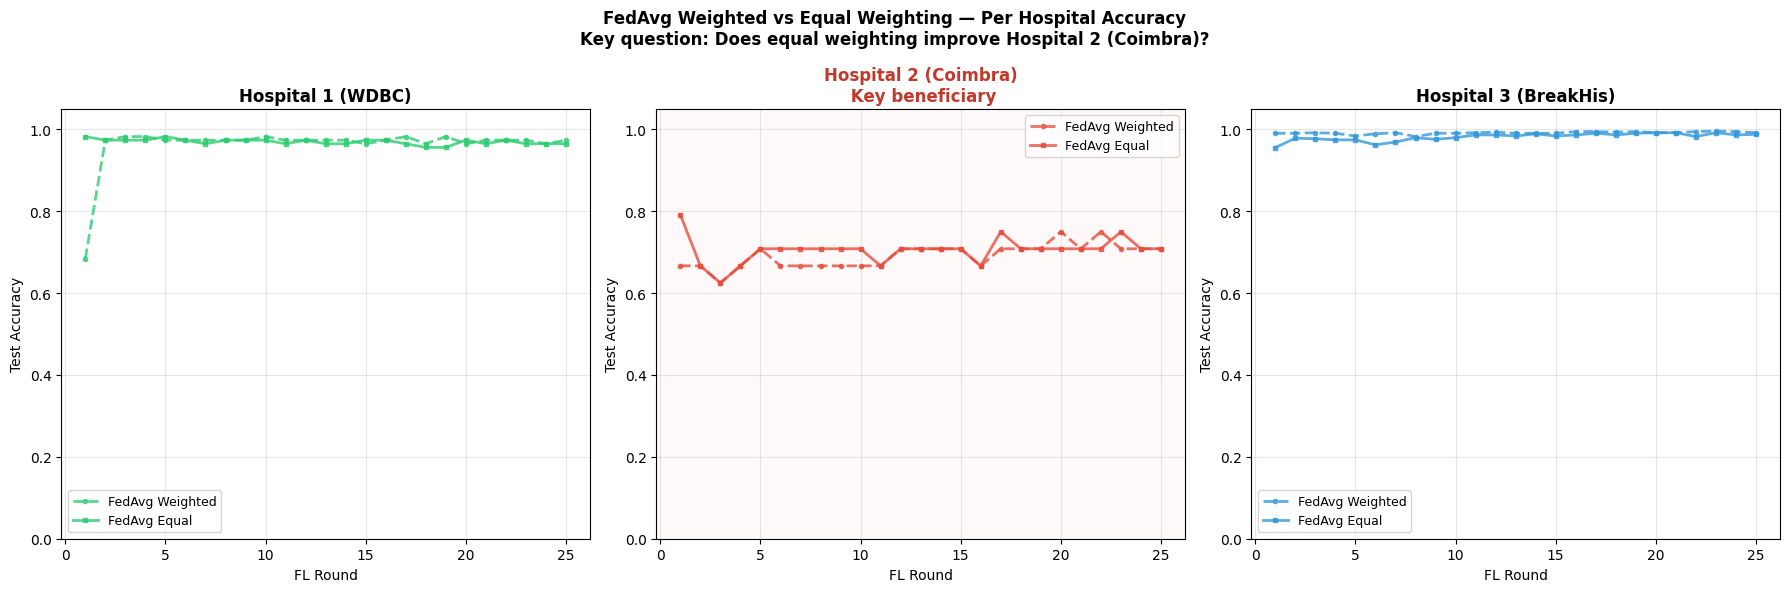


 Comparison plot saved


In [ ]:
# Loading weighted FedAvg history from saved JSON
# fl_history was saved in Phase 4 Cell 5
# Loading from file ensures it is always available
# regardless of kernel state
import json

with open(
    'results/federated/fl_history.json',
    'r', encoding='utf-8'
) as f:
    fl_history = json.load(f)

print(" Weighted FedAvg history loaded from results/federated/fl_history.json")
print(f"   Rounds available : {len(fl_history['round'])}")
print(f"   H2 best accuracy : {max(fl_history['h2_test_acc']):.4f}")

# Direct comparison: Weighted FedAvg vs Equal FedAvg
# Focusing on Hospital 2 improvement — key finding
import matplotlib.pyplot as plt

best_round_eq = fl_history_eq['round'][
    np.argmax(fl_history_eq['avg_test_acc'])
]

# Best metrics from equal FedAvg
best_idx_eq = np.argmax(fl_history_eq['avg_test_acc'])
eq_h1_acc   = fl_history_eq['h1_test_acc'][best_idx_eq]
eq_h2_acc   = fl_history_eq['h2_test_acc'][best_idx_eq]
eq_h3_acc   = fl_history_eq['h3_test_acc'][best_idx_eq]
eq_h1_f1    = fl_history_eq['h1_test_f1'][best_idx_eq]
eq_h2_f1    = fl_history_eq['h2_test_f1'][best_idx_eq]
eq_h3_f1    = fl_history_eq['h3_test_f1'][best_idx_eq]
eq_h1_auc   = fl_history_eq['h1_test_auc'][best_idx_eq]
eq_h2_auc   = fl_history_eq['h2_test_auc'][best_idx_eq]
eq_h3_auc   = fl_history_eq['h3_test_auc'][best_idx_eq]

# Best metrics from weighted FedAvg (Phase 4)
best_idx_w  = np.argmax(fl_history['avg_test_acc'])
w_h1_acc    = fl_history['h1_test_acc'][best_idx_w]
w_h2_acc    = fl_history['h2_test_acc'][best_idx_w]
w_h3_acc    = fl_history['h3_test_acc'][best_idx_w]
w_h1_f1     = fl_history['h1_test_f1'][best_idx_w]
w_h2_f1     = fl_history['h2_test_f1'][best_idx_w]
w_h3_f1     = fl_history['h3_test_f1'][best_idx_w]
w_h1_auc    = fl_history['h1_test_auc'][best_idx_w]
w_h2_auc    = fl_history['h2_test_auc'][best_idx_w]
w_h3_auc    = fl_history['h3_test_auc'][best_idx_w]

# Printing comparison table
print(f"\n{'='*65}")
print(f"  WEIGHTED vs EQUAL FedAvg COMPARISON")
print(f"{'='*65}")
print(f"  {'Hospital':<25} {'Metric':<10} {'Weighted':>10} "
      f"{'Equal':>10} {'Delta':>10}")
print(f"  {'─'*63}")

hospitals_list = [
    ('Hospital 1 (WDBC)',     w_h1_acc, eq_h1_acc,
                              w_h1_f1,  eq_h1_f1,
                              w_h1_auc, eq_h1_auc),
    ('Hospital 2 (Coimbra)',  w_h2_acc, eq_h2_acc,
                              w_h2_f1,  eq_h2_f1,
                              w_h2_auc, eq_h2_auc),
    ('Hospital 3 (BreakHis)', w_h3_acc, eq_h3_acc,
                              w_h3_f1,  eq_h3_f1,
                              w_h3_auc, eq_h3_auc),
]

for name, wa, ea, wf, ef, wu, eu in hospitals_list:
    print(f"\n  {name}")
    print(f"  {'':25} {'Accuracy':<10} {wa:>10.4f} "
          f"{ea:>10.4f} {ea-wa:>+10.4f}")
    print(f"  {'':25} {'F1-Score':<10} {wf:>10.4f} "
          f"{ef:>10.4f} {ef-wf:>+10.4f}")
    print(f"  {'':25} {'AUC-ROC':<10} {wu:>10.4f} "
          f"{eu:>10.4f} {eu-wu:>+10.4f}")

print(f"\n{'='*65}")
print(f"  KEY FINDING — Hospital 2 (Coimbra) improvement:")
print(f"  Accuracy delta : {eq_h2_acc - w_h2_acc:+.4f}")
print(f"  F1 delta       : {eq_h2_f1  - w_h2_f1:+.4f}")
print(f"  AUC delta      : {eq_h2_auc - w_h2_auc:+.4f}")
print(f"{'='*65}")

# Plot — H2 accuracy over rounds for both methods
# Focus plot on Coimbra since it is the key beneficiary
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'FedAvg Weighted vs Equal Weighting — Per Hospital Accuracy\n'
    'Key question: Does equal weighting improve Hospital 2 (Coimbra)?',
    fontsize=12, fontweight='bold'
)

hospital_labels = [
    'Hospital 1 (WDBC)',
    'Hospital 2 (Coimbra)',
    'Hospital 3 (BreakHis)'
]
weighted_accs = [
    fl_history['h1_test_acc'],
    fl_history['h2_test_acc'],
    fl_history['h3_test_acc']
]
equal_accs = [
    fl_history_eq['h1_test_acc'],
    fl_history_eq['h2_test_acc'],
    fl_history_eq['h3_test_acc']
]
colors = ['#2ECC71', '#E74C3C', '#3498DB']

for i, ax in enumerate(axes):
    ax.plot(
        fl_history['round'], weighted_accs[i],
        color=colors[i], linestyle='--',
        linewidth=2, marker='o', markersize=3,
        label='FedAvg Weighted', alpha=0.8
    )
    ax.plot(
        fl_history_eq['round'], equal_accs[i],
        color=colors[i], linestyle='-',
        linewidth=2, marker='s', markersize=3,
        label='FedAvg Equal', alpha=0.8
    )
    ax.set_title(hospital_labels[i], fontweight='bold')
    ax.set_xlabel('FL Round')
    ax.set_ylabel('Test Accuracy')
    ax.set_ylim([0.0, 1.05])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Highlight Hospital 2 as key finding
    if i == 1:
        ax.set_facecolor('#FFF9F9')
        ax.set_title(
            f'{hospital_labels[i]}\n Key beneficiary',
            fontweight='bold', color='#C0392B'
        )

plt.tight_layout()
plt.savefig(
    'results/federated/equal/weighted_vs_equal_comparison.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print("\n Comparison plot saved")

### Summary

In [ ]:

print("\n" + "="*70)
print("  STEP 1 COMPLETE — FedAvg EQUAL WEIGHTING")
print("="*70)

summary_eq = f"""
Algorithm     : FedAvg Equal Weighting
FL rounds     : {num_fl_rounds_eq}
Local epochs  : {local_epochs_eq}
H1 weight     : 33.3% (was 21.5%)
H2 weight     : 33.3% (was  3.5%)
H3 weight     : 33.3% (was 75.0%)
Best round    : {best_round_eq}

Results (best round):
              Weighted FedAvg    Equal FedAvg    Delta
H1 Accuracy   {w_h1_acc:.4f}             {eq_h1_acc:.4f}          {eq_h1_acc-w_h1_acc:+.4f}
H2 Accuracy   {w_h2_acc:.4f}             {eq_h2_acc:.4f}          {eq_h2_acc-w_h2_acc:+.4f}
H3 Accuracy   {w_h3_acc:.4f}             {eq_h3_acc:.4f}          {eq_h3_acc-w_h3_acc:+.4f}

H1 F1-Score   {w_h1_f1:.4f}             {eq_h1_f1:.4f}          {eq_h1_f1-w_h1_f1:+.4f}
H2 F1-Score   {w_h2_f1:.4f}             {eq_h2_f1:.4f}          {eq_h2_f1-w_h2_f1:+.4f}
H3 F1-Score   {w_h3_f1:.4f}             {eq_h3_f1:.4f}          {eq_h3_f1-w_h3_f1:+.4f}

Saved files:
  results/federated/equal/fl_history_eq.json
  results/federated/equal/weighted_vs_equal_comparison.png
  models/federated/equal/best_global_shared_head_eq.pth
  models/federated/equal/best_h1_fedavg_eq.pth
  models/federated/equal/best_h2_fedavg_eq.pth
  models/federated/equal/best_h3_fedavg_eq.pth

Next: Step 2 — FedProx
"""

print(summary_eq)

with open(
    'results/federated/equal/step1_summary.txt',
    'w', encoding='utf-8'
) as f:
    f.write(summary_eq)

print(" Summary saved: results/federated/equal/step1_summary.txt")


  STEP 1 COMPLETE — FedAvg EQUAL WEIGHTING

Algorithm     : FedAvg Equal Weighting
FL rounds     : 25
Local epochs  : 2
H1 weight     : 33.3% (was 21.5%)
H2 weight     : 33.3% (was  3.5%)
H3 weight     : 33.3% (was 75.0%)
Best round    : 1

Results (best round):
              Weighted FedAvg    Equal FedAvg    Delta
H1 Accuracy   0.9825             0.9825          +0.0000
H2 Accuracy   0.7083             0.7917          +0.0833
H3 Accuracy   0.9946             0.9556          -0.0390

H1 F1-Score   0.9762             0.9756          -0.0006
H2 F1-Score   0.7200             0.8148          +0.0948
H3 F1-Score   0.9961             0.9685          -0.0277

Saved files:
  results/federated/equal/fl_history_eq.json
  results/federated/equal/weighted_vs_equal_comparison.png
  models/federated/equal/best_global_shared_head_eq.pth
  models/federated/equal/best_h1_fedavg_eq.pth
  models/federated/equal/best_h2_fedavg_eq.pth
  models/federated/equal/best_h3_fedavg_eq.pth

Next: Step 2 — FedProx